## SimpleRNN — Results Summary

- **Model:** SimpleRNN (2 layers)
- **Architecture:** Embedding(50000, 128) → RNN(64) → Dropout(0.5) → RNN(32) → Dropout(0.5) → Dense(3)
- **Class weights:** balanced
- **Preprocessing:** lowercase, remove URLs, remove emojis
- **Early stopping:** patience=3, restored best weights at epoch 4

**Overall Test Results:**
- Macro F1:  0.68
- Accuracy:  0.68

**Per-Language Results:**
- Hausa achieved a Macro F1 of 0.70
- Igbo achieved a Macro F1 of 0.72
- Pidgin achieved a Macro F1 of 0.43 — the worst (Pidgin neutral F1: 0.08)
- Yoruba achieved a Macro F1 of 0.66

**Key Findings:**
- Model overfit severely without regularisation — val loss reached 2.05 at epoch 9
- Adding Dropout(0.5), L2 regularisation and early stopping fixed overfitting
- Early stopping halted training at epoch 4 — best generalisation point
- RNN improved neutral prediction slightly over LogReg (0.67 vs 0.66)
- Sequential processing helps capture hedging patterns in neutral tweets
- Pidgin neutral remains broken — 72 training samples is a data problem, not a model problem
- Yoruba performance dropped slightly vs LogReg — diacritics handled inconsistently by Keras tokenizer
- SimpleRNN did not beat Logistic Regression — expected due to vanishing gradient limitations on short tweets

**vs Logistic Regression Baseline:**
- Overall: 0.68 vs 0.69 — marginally behind
- Neutral class: 0.67 vs 0.66 — RNN slightly better
- Pidgin: 0.43 vs 0.44 — virtually identical

**Next: LSTM — gated memory should improve on vanishing gradient limitations.**

In [1]:
import pandas as pd
import numpy as np
import re
import nltk

import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# load the datasets
df_train = pd.read_csv('../01-data/02-processed/train_clean.csv')
df_test = pd.read_csv('../01-data/02-processed/test_clean.csv')
df_val = pd.read_csv('../01-data/02-processed/val_clean.csv')

In [3]:
def dataset_preprocessing(text):
    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
    )

    text = emoji_pattern.sub('', text)

    return text.strip()

In [4]:
# drop tweet length from train dataset
df_train.drop(columns=['tweet_length'], inplace=True)

df_list = [df_train, df_test, df_val]
for df in df_list:
    df['cleaned_tweet'] = df['tweet'].apply(dataset_preprocessing)
    df.drop(columns=['tweet'], inplace=True)
    df.rename(columns={'cleaned_tweet': 'tweet'}, inplace=True)

In [5]:
# split dataset for training, validation and testing
X_train = df_train['tweet']
y_train = df_train['label']
X_test = df_test['tweet']
y_test = df_test['label']
X_val = df_val['tweet']
y_val = df_val['label']

In [6]:
def preparation_for_model_train(X_train, X_test, X_val, 
                                y_train, y_test, y_val, 
                                vocab_size = 50000, max_len= 50):

    tokenizer = Tokenizer(num_words=vocab_size)

    tokenizer.fit_on_texts(X_train)

    # convert text to numbers

    X_train_seq = tokenizer.texts_to_sequences(X_train)

    X_val_seq = tokenizer.texts_to_sequences(X_val)

    X_test_seq = tokenizer.texts_to_sequences(X_test)

    # pad the sequences because RNN requires the same input size
    # we will choose 50 as the max length as prosposed during the eda process


    X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)

    X_val_pad = pad_sequences(X_val_seq, maxlen=max_len)

    X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

    label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}

    y_train = y_train.map(label_mapping).values

    y_val   = y_val.map(label_mapping).values

    y_test = y_test.map(label_mapping).values

    return X_train_pad, X_val_pad, X_test_pad, y_train, y_val, y_test

In [7]:
X_train_pad, X_val_pad, X_test_pad, y_train, y_val, y_test = preparation_for_model_train(
    X_train, X_test, X_val, y_train, y_test, y_val, vocab_size = 50000, max_len= 50
)

In [8]:
def build_simple_rnn_model(
        vocab_size=50000,
        embedding_dim=128,
        hidden_size1=128,
        hidden_size2=64,
        dropout_rate=0.5
):
    model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
        ),

    SimpleRNN(
        units=hidden_size1,
        return_sequences=True
        ),

    Dropout(dropout_rate),

    SimpleRNN(hidden_size2),
    
    Dropout(dropout_rate),

    Dense(3, activation="softmax")

    ])

    # compile the model
    model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
    )

    return model

In [9]:
model = build_simple_rnn_model()

In [10]:
# compute and add class weights because of the limited 
# representation of the neutral sentiment for pidgin class
classes = np.array([0, 1, 2])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(enumerate(weights))

early_stop = EarlyStopping(
    monitor='val_loss',    # watch validation loss
    patience=3,            # wait 3 epochs before stopping
    restore_best_weights=True  # roll back to best epoch weights
)

# Then in model.fit:
history = model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=20,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stop]
)

Epoch 1/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 99s 74ms/step - accuracy: 0.5718 - loss: 0.9024 - val_accuracy: 0.6910 - val_loss: 0.7160
Epoch 2/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 85s 74ms/step - accuracy: 0.7942 - loss: 0.5298 - val_accuracy: 0.7069 - val_loss: 0.7337
Epoch 3/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 96s 84ms/step - accuracy: 0.9023 - loss: 0.2742 - val_accuracy: 0.6998 - val_loss: 0.8792
Epoch 4/20
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 134s 77ms/step - accuracy: 0.9503 - loss: 0.1500 - val_accuracy: 0.6872 - val_loss: 1.0806


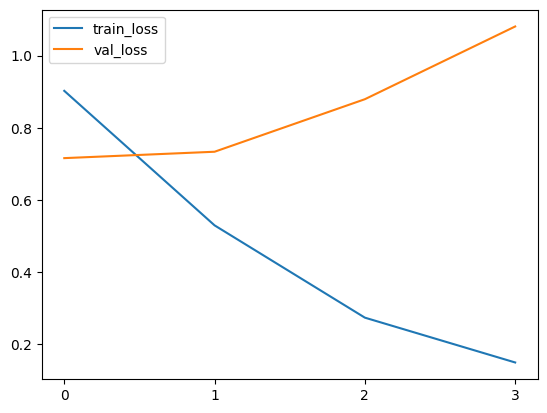

In [11]:
# plot the loss and validation loss
epochs_ran = len(history.history['loss'])

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xticks(np.arange(epochs_ran))
plt.legend()
plt.show()

In [12]:
predict = model.predict(X_test_pad)

y_pred = np.argmax(predict, axis=1)

f1 = f1_score(y_test, y_pred, average='macro')

print(f'f1_macro: {f1}')
print("="*50)
print('CLASSIFICATION REPORT')
print("="*50)
print(classification_report(y_test, y_pred, target_names=['negative','neutral','positive']))

552/552 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step
f1_macro: 0.6666926157084462
CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.59      0.78      0.67      6009
     neutral       0.69      0.60      0.64      5457
    positive       0.78      0.63      0.69      6188

    accuracy                           0.67     17654
   macro avg       0.68      0.67      0.67     17654
weighted avg       0.68      0.67      0.67     17654



In [13]:
reverse_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
df_test['predicted'] = y_pred
df_test['predicted'] = df_test['predicted'].map(reverse_mapping)

for lang in ['hausa', 'igbo', 'pidgin', 'yoruba']:
    subset = df_test[df_test['language'] == lang]
    print(f"\n{'='*50}")
    print(f"Language: {lang.upper()}")
    print(f"{'='*50}")
    print(classification_report(subset['label'], subset['predicted'],
                                target_names=['negative','neutral','positive']))


Language: HAUSA
              precision    recall  f1-score   support

    negative       0.59      0.76      0.66      1759
     neutral       0.69      0.55      0.61      1789
    positive       0.83      0.76      0.79      1755

    accuracy                           0.69      5303
   macro avg       0.70      0.69      0.69      5303
weighted avg       0.70      0.69      0.69      5303


Language: IGBO
              precision    recall  f1-score   support

    negative       0.67      0.70      0.68       943
     neutral       0.72      0.78      0.75      1621
    positive       0.85      0.71      0.77      1118

    accuracy                           0.74      3682
   macro avg       0.75      0.73      0.73      3682
weighted avg       0.75      0.74      0.74      3682


Language: PIDGIN
              precision    recall  f1-score   support

    negative       0.61      0.89      0.72      2326
     neutral       0.38      0.03      0.06       431
    positive       0.58 